In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import copy
import sys
sys.path.insert(1, '../Utilities/')

In [2]:
from sampling import *

In [3]:
from AutoDiff import *
from pinns_weights import *
from utils import *
from Trainer import Trainer

In [4]:
from PINNs import Stefan_pinn

In [5]:
from matplotlib import rc
#rc('text', usetex=True)
rc('xtick', direction='in', top=True)
rc('ytick', direction='in', right=True)

In [6]:
savefile = "outputs_2D/"
save = True

### Params

In [7]:
ti = 0.011
tf = 0.19

Ste = 0.05
Fo = 1.
delta = 0.05

Th = 1.
Tc = -2

### Ref. Solution

In [8]:
file = '../Utilities/Ref/ref2D_0.5'
visu_data = np.loadtxt(file, delimiter=",")
of = open(file)
of.readlines()[0]

'# Ste=0.500000, Fo=1.000000, delta=0.050000, n_xy=41, n_t=16\n'

In [11]:
nxy = 41
nt = 16

In [12]:
times = []
T_ref = []
for sol in np.vsplit(visu_data, nt):
    times.append(sol[0, 0])
    T_ref.append(sol[:, 3].reshape(nxy, nxy))

x_grid = sol[:, 1].reshape(nxy, nxy)
y_grid = sol[:, 2].reshape(nxy, nxy)

x = np.diag(x_grid)
y = np.diag(x_grid)

In [13]:
levels = np.linspace(-2, 1., 10)
cmap='coolwarm'

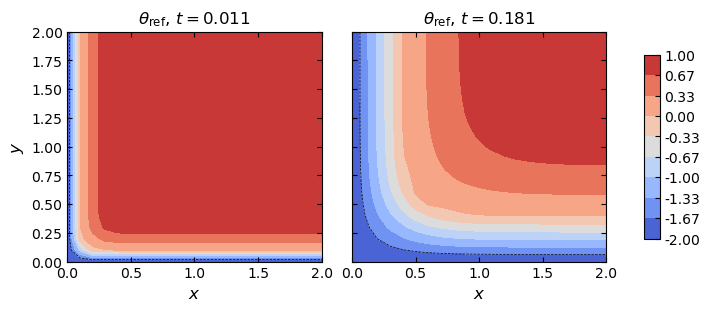

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

i = 0
j = -1

ctf = axs[0].contourf(x_grid, y_grid, T_ref[i], levels, cmap=cmap)
ct = axs[0].contour(x_grid, y_grid, T_ref[i], levels=[levels[1]], colors='black', linewidths=0.5)

ctf = axs[1].contourf(x_grid, y_grid, T_ref[j], levels, cmap=cmap)
ct = axs[1].contour(x_grid, y_grid, T_ref[j], levels=[levels[1]], colors='black', linewidths=0.5)

cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.2f')

axs[0].set_title(r"$\theta_\mathrm{ref}$, $t = %.3f$"%(times[i]))
axs[1].set_title(r"$\theta_\mathrm{ref}$, $t = %.3f$"%(times[j]))


""""
x1, x2, y1, y2 = 0., 1, 0., 1
for i in [0, -1]:
    axins = axs[i].inset_axes([0.65, 0.65, 0.3, 0.3], xticks=[1], yticks=[0, 1])
    axins.contourf(x_grid, y_grid, T_ref[i], levels, cmap=cmap)
    axins.tick_params(labelsize=5)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
"""

#"""
axs[0].set_xlim(0., 2)
axs[0].set_ylim(0., 2)
axs[1].set_xlim(0., 2)
axs[1].set_ylim(0., 2)
#"""

axs[0].set_ylabel('$y$', fontsize = 12)
axs[0].set_xlabel('$x$', fontsize = 12)
axs[1].set_xlabel('$x$', fontsize = 12)

if save:
    plt.savefig(savefile+"2D_ref.pdf")
    plt.savefig(savefile+"2D_ref.png")
plt.show()

In [15]:
class stefan_problem(Trainer):
    
    def __init__(self, model, 
                 ics_sampler, bcs_sampler, res_sampler,
                 n_ics, n_bcs, n_res,
                 validation_data = None):
        super().__init__(model, validation_data)
        *self.ics_in, self.ics_out = ics_sampler.sample(n_ics, device=self.device)
        *self.bcs1_in, self.bcs1_out = bcs_sampler[0].sample(n_bcs, device=self.device)
        *self.bcs2_in, self.bcs2_out = bcs_sampler[1].sample(n_bcs, device=self.device)
        *self.res_in, _= res_sampler.sample(n_res, device=self.device)
        self.res_sampler = res_sampler
        self.validation_data_is_available = False
        if validation_data is not None:
            if not torch.is_tensor(validation_data):
                validation_data = torch.Tensor(validation_data).to(self.device)
            *self.val_in, self.val_out = np.split(validation_data, 4, 1)
            self.validation_data_is_available = True
            
        self.weights_dict = {'ics': [], 'bcs': [], 'res': []}
        self.losses_dict = {'ics': [], 'bcs': [], 'res': [], 'total':[], 'l2': []}
        
    def loss_fn(self):
        # initial conditions
        ics = self.net(*self.ics_in)
        ics_mse, ics_error = self.mse_error(ics, self.ics_out)
        
        # Dirichlet boundary conditions
        bcs1 = self.net(*self.bcs1_in)
        bcs1_mse, bcs1_error = self.mse_error(bcs1, self.bcs1_out)
        
        # Neumann boundary conditions
        _ , Tx, Ty = self.net_grad(*self.bcs2_in)
        nx = torch.where(self.bcs2_in[1]==4., 1., 0.) # 1. where x==4., zero otherwise
        ny = torch.where(self.bcs2_in[2]==4., 1., 0.) # 1. where y==4., zero otherwise
        bcs21_mse, bcs21_error = self.mse_error(Tx* nx)
        bcs22_mse, bcs22_error = self.mse_error(Ty* ny)
        bcs2_mse = bcs21_mse + bcs22_mse
        # PDE
        res = self.net_res(*self.res_in)
        res_mse, res_error = self.mse_error(res)
        
        losses = (ics_mse, bcs1_mse + bcs2_mse, res_mse)
        errors = (ics_error, bcs1_error, bcs21_error, bcs22_error, res_error)
        return losses, errors
        
        losses = (ics_mse, bcs1_mse + bcs2_mse, res_mse)
        errors = (ics_error, bcs1_error, bcs21_error, bcs22_error, res_error)
        return losses, errors

    
    def train(self, num_epochs, weighting_dict, optim_dict, l2_frequency=1000):
        
        weighting_dict = self._set_weights(weighting_dict)
        self._set_opt(weighting_dict, optim_dict)

        epochs = tqdm(range(num_epochs))
        for epoch in epochs:
            
            """ To Do
            if adaptive:
                if epoch !=0 and epoch % 100 == 0:
                    *self.res_in, _ , res_weights = self.res_sampler._update(self.res_in, save=True)
            """
            
            closure = lambda: self.closure_fn(epoch, weighting_dict)
            loss = self.step(closure)

            # Save losses and weights
            for i, (ll, wl) in enumerate(zip(self.losses_dict.values(), self.weights_dict.values())):
                ll.append(self._last_losses[i])
                wl.append(self.loss_weights[i])
            self.losses_dict["total"].append(loss.item())
            
            epochs.set_description('total loss : %.2e' %(loss.item()))
            if self.validation_data_is_available and (epoch % l2_frequency)==0:
                self.validation_error(epoch)   

In [16]:
layers = [3] + 6* [45] + [1]
activations = "Tanh"

In [17]:
model = Stefan_pinn(layers, activations, Ste, Fo, delta, dim=2, seed=123)

In [18]:
xl, xu = 0., 4.
yl, yu = 0., 4.
ones = lambda *args: np.ones_like(args[0])

bc1_sampler = Sampler([ti, xl, yl], [tf, xl, yu], lambda *args: Tc*ones(*args))
bc2_sampler = Sampler([ti, xu, yl], [tf, xu, yu])
bc3_sampler = Sampler([ti, xl, yl], [tf, xu, yl], lambda *args: Tc*ones(*args))
bc4_sampler = Sampler([ti, xl, yu], [tf, xu, yu])

bcs1_sampler = Join_samplers([bc1_sampler, bc3_sampler]) # Direclet bcs
bcs2_sampler = Join_samplers([bc2_sampler, bc4_sampler]) # Neumann bcs
bcs_sampler = [bcs1_sampler, bcs2_sampler]

In [19]:
file = '../Utilities/Ref/ref2D_0.5_T0'
ics = np.loadtxt(file, delimiter=",")
ics_sampler = data_sampler(ics)

In [20]:
t0, x0, y0, T0 = ics_sampler.sample(ics_sampler.n)
t0 = t0.cpu().detach().flatten()
x0 = x0.cpu().detach().flatten()
y0 = y0.cpu().detach().flatten()
T0 = T0.cpu().detach().flatten()

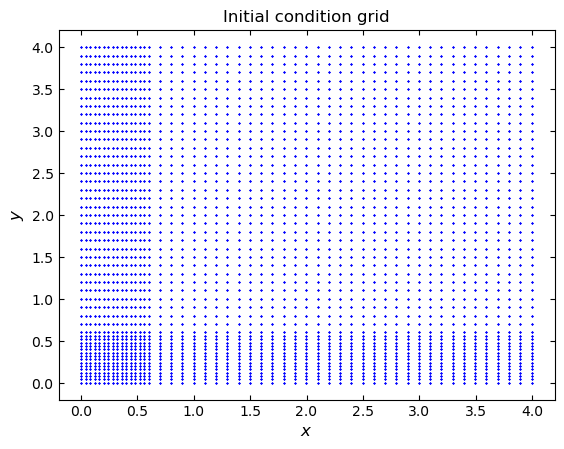

In [21]:
fig, ax = plt.subplots(1, 1)

#cb = ax.tricontourf(x0, y0, T0, cmap="coolwarm")
#fig.colorbar(cb)

ax.scatter(x0, y0, c='b', s=.5, marker="x")
#plt.xlim(-0.001, 1.0001)

ax.set_title("Initial condition grid")
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("$y$", fontsize=12)

plt.savefig(savefile+"grid.pdf", bbox_inches ='tight')
plt.savefig(savefile+"grid.png", bbox_inches ='tight')
plt.show()

In [22]:
n_ics = ics_sampler.n
n_ics

2500

In [23]:
res_sampler = Sampler(
    l_bounds=[ti, xl, yl],
    u_bounds=[tf, xu, yu]
)

In [24]:
n_ics = ics_sampler.n
n_bcs = 4* 256
n_res = 25000

In [25]:
n_ics

2500

In [26]:
n_bcs

1024

In [25]:
file = '../Utilities/Ref/ref2D_0.5'
validation_data = np.loadtxt(file, delimiter=",")
of = open(file)
of.readlines()[0]

'# Ste=0.500000, Fo=1.000000, delta=0.050000, n_xy=41, n_t=16\n'

In [26]:
stefan_trainer = stefan_problem(
    model, 
    ics_sampler, bcs_sampler, res_sampler, 
    n_ics, n_bcs, n_res,
    validation_data=validation_data
)

#### Adam 

In [27]:
weighting_dict = {
    "method": "lr_anneling",
    "frequency": 100,
    "alpha": .1,
    "sup": float('inf')
}   

In [28]:
optim_dict = {
    'optimizer': 'Adam',
    'lr': 1e-3,
    'exp_lr': True
}
l2_frequency = 1

In [32]:
%%time

n_epochs = 50000
stefan_trainer.train(
    n_epochs, 
    optim_dict=optim_dict,
    weighting_dict=weighting_dict,
    l2_frequency=l2_frequency
)

/home/bmadir/miniconda3/envs/jupyter/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  0%|          | 0/50000 [00:00<?, ?it/s]

CPU times: user 20min 39s, sys: 10.4 s, total: 20min 49s
Wall time: 21min 2s


#### LBFGS 

In [29]:
weights = [100, 50, 1]
#weights = stefan_trainer.loss_weights
weights

[100, 50, 1]

In [30]:
weighting_dict = {
    "method": None,
    "weights": weights
}

In [31]:
optim_dict = dict(
    optimizer="LBFGS",
    max_iter=50,
    line_search_fn="strong_wolfe",
    history_size=100,
    tolerance_grad=1e-7
)

l2_frequency = 1

In [32]:
%%time

n_epochs = 1000
stefan_trainer.train(
    n_epochs, 
    optim_dict=optim_dict,
    weighting_dict=weighting_dict,
    l2_frequency=1
)

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/bmadir/miniconda3/envs/jupyter/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


CPU times: user 7min 17s, sys: 2.08 s, total: 7min 19s
Wall time: 7min 26s


In [33]:
if save:
    model.save(file=savefile)
    stefan_trainer.save(file=savefile, weights=True)

### Losses:

In [34]:
n_epochs = 2000

losses = stefan_trainer.losses_dict
l2_ep = range(n_epochs)[::l2_frequency]

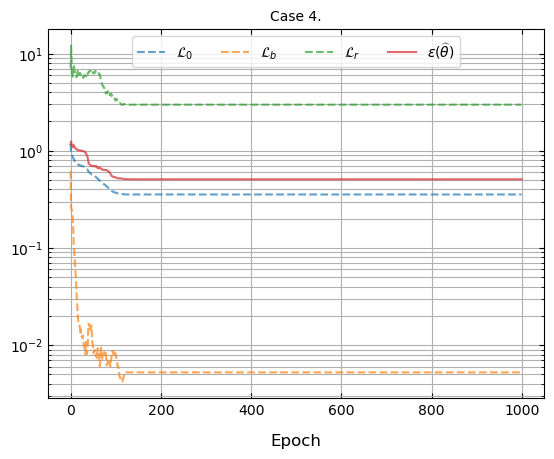

In [35]:
fig, ax = plt.subplots(1, 1)

ax.plot(losses['ics'], '--', label='$\mathcal{L}_{0}$', alpha=.7)
ax.plot(losses['bcs'], '--', label='$\mathcal{L}_{b}$', alpha=.7)
ax.plot(losses['res'], '--', label='$\mathcal{L}_{r}$', alpha=.7)
ax.plot(losses['l2'], '-', label=r'$\epsilon(\widehat\theta)$', alpha=.7)

ax.grid(True, "both")
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize = 12, labelpad=12)
#ax.set_ylabel('Loss', fontsize = 12, labelpad=12)
ax.set_title('Case 4.', fontsize = 10)

#ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3))
ax.legend(loc="upper center", ncol=4)

if save:
    plt.savefig(savefile + 'losses.pdf', bbox_inches ='tight')
    plt.savefig(savefile + 'losses.png', bbox_inches ='tight')
plt.show()

In [36]:
try:
    print(f"ics error: {losses['ics'][-1]: .3e}")
    print(f"bcs error: {losses['bcs'][-1]: .3e}")
    print(f"res error: {losses['res'][-1]: .3e}")
    print(f"l2 error: {losses['l2'][-1]: .3e}")
    print(f"min l2 error: {min(losses['l2']): .3e}")
except: pass

ics error:  3.545e-01
bcs error:  5.244e-03
res error:  2.976e+00
l2 error:  5.079e-01
min l2 error:  5.079e-01


In [37]:
np.argmin(losses['l2'])

123

### Weights:

In [38]:
weights = stefan_trainer.weights_dict
every = 1
weights_ep = range(n_epochs)[::every]

100.0 50.0 1.0


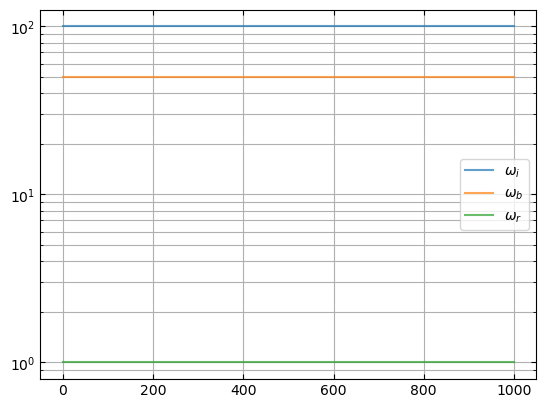

In [39]:
print(np.mean(weights['ics']), np.mean(weights['bcs']), np.mean(weights['res']))

plt.grid(True, which='both')
plt.yscale('log')

plt.plot(weights['ics'][::every], label='$\omega_i$', alpha=.7)
plt.plot(weights['bcs'][::every], label='$\omega_b$', alpha=.7)
plt.plot(weights['res'][::every], label='$\omega_r$', alpha=.7)

plt.legend()


if save:
    plt.savefig(savefile +'weights.pdf', bbox_inches ='tight')
    plt.savefig(savefile +'weights.png', bbox_inches ='tight')
plt.show()

### Solution:

In [40]:
def pred(t):
    return model.evaluate(
        t* ones(x_grid.reshape(-1, 1)),
        x_grid.reshape(-1, 1),
        y_grid.reshape(-1, 1)
    ).reshape(nxy, nxy)

In [41]:
T_pred = []

for i, t in enumerate(times):
    T_pred.append(pred(t))
    
x = np.diag(x_grid)
y = np.diag(y_grid)

In [42]:
i = 0
j = -1

erri = np.abs(T_ref[i] - T_pred[i])
errj = np.abs(T_ref[j] - T_pred[j])

levels = np.linspace(0, max(erri.max(), errj.max()), 10)

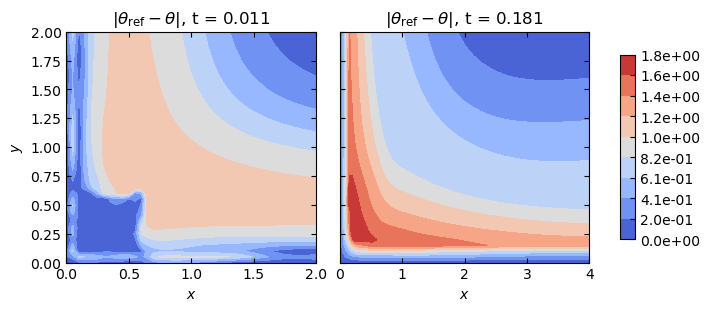

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

ctf = axs[0].contourf(x_grid, y_grid, np.abs(T_ref[i] - T_pred[i]), levels=levels, cmap=cmap)
ctf = axs[1].contourf(x_grid, y_grid, np.abs(T_ref[j] - T_pred[j]), levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.1e')


axs[0].set_xlim(0, 2)
axs[0].set_ylim(0, 2)


axs[0].set_title(r"$|\theta_\mathrm{ref} - \theta|$, t = %.3f"%(times[i]))
axs[1].set_title(r"$|\theta_\mathrm{ref} - \theta|$, t = %.3f"%(times[j]))

axs[0].set_ylabel('$y$', fontsize = 10)
axs[0].set_xlabel('$x$', fontsize = 10)
axs[1].set_xlabel('$x$', fontsize = 10)

if save:
    plt.savefig(savefile+"2D_abs_error.pdf")
    plt.savefig(savefile+"2D_abs_error.png")
plt.show()

In [44]:
levels = np.linspace(0, errj.max(), 10)

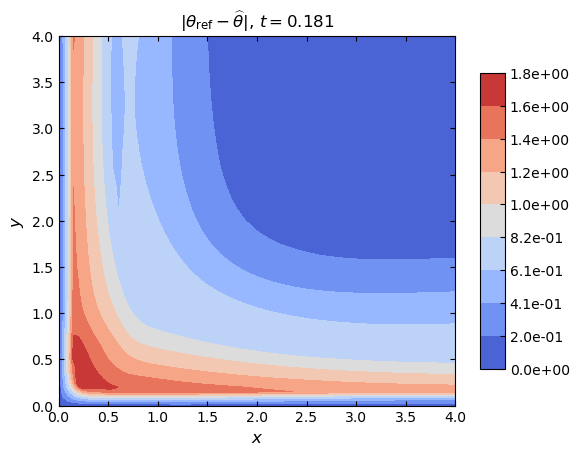

In [45]:
fig, axs = plt.subplots(1, 1)

axs = [axs]
ctf = axs[0].contourf(x_grid, y_grid, errj, levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.1e')

axs[0].set_title(r"$|\theta_\mathrm{ref} - \widehat\theta|$, $t = 0.181$")

axs[0].set_ylabel('$y$', fontsize = 12)
axs[0].set_xlabel('$x$', fontsize = 12)

if save:
    plt.savefig(savefile+"2D_abs_error.pdf")
    plt.savefig(savefile+"2D_abs_error.png")
plt.show()

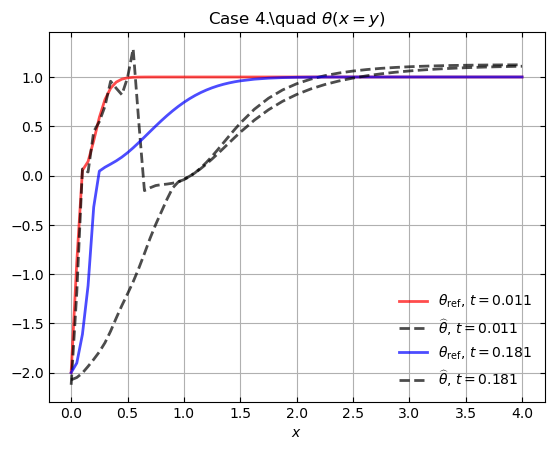

In [46]:
fig, axs = plt.subplots(1, 1)

axs.grid(True)
axs.plot(x, np.diag(T_ref[0]), lw=2, c='red', alpha=.7, label=r'$\theta_\mathrm{ref}$, $t=%.3f$'%(times[0]))
axs.plot(x, np.diag(T_pred[0]), '--k', lw=2, alpha=.7, label=r'$\widehat\theta$, $t=%.3f$'%(times[0]))

axs.plot(x, np.diag(T_ref[-1]), '-b',lw=2, alpha=.7, label=r'$\theta_\mathrm{ref}$, $t=%.3f$'%(times[-1]))
axs.plot(x, np.diag(T_pred[-1]), '--k', lw=2, alpha=.7, label=r'$\widehat\theta$, $t=%.3f$'%(times[-1]))
axs.set_xlabel('$x$', fontsize = 10)
#axs.set_ylabel(r'$\theta$, $y = x$', fontsize = 10)

axs.set_title(r'Case 4.\quad $\theta(x=y)$', fontsize=12)
axs.legend(loc='lower right', ncol=1, frameon=False)

if save:
    plt.savefig(savefile+"2D_results_bis.pdf")
    plt.savefig(savefile+"2D_results_bis.png")
plt.show()

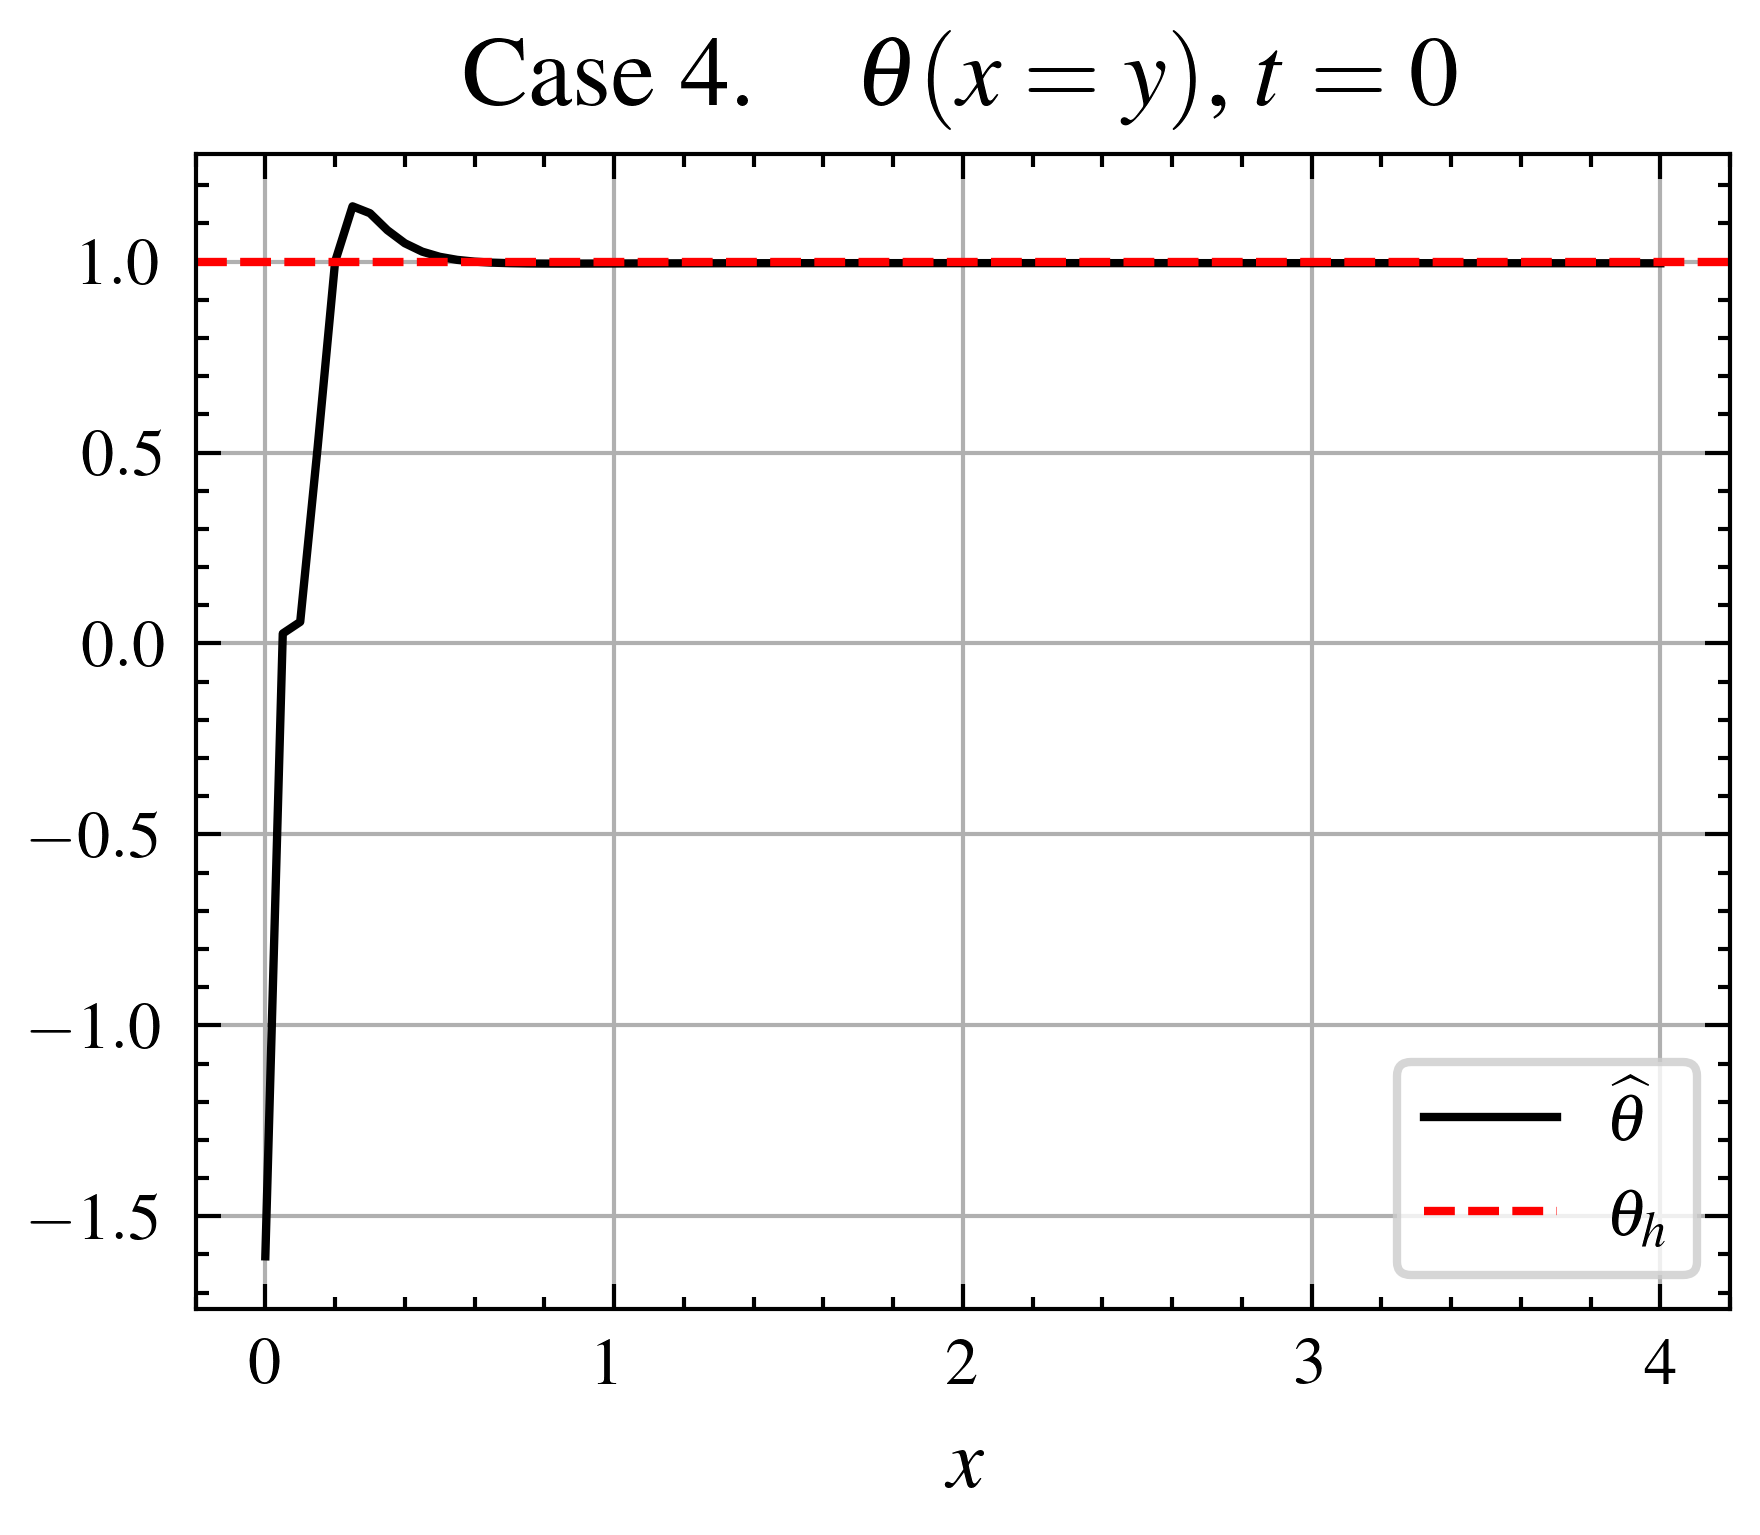

In [63]:
fig, axs = plt.subplots(1, 1)
axs.grid(True)

t = 0
axs.plot(x, np.diag(pred(t)), label=r'$\widehat\theta$')
axs.axhline(1, c='r', ls='--', label=r'$\theta_h$')
axs.set_title(r"Case 4. $\theta(x=y)$, $t = 0$")

axs.set_title(r'Case 4.\quad $\theta(x=y)$, $t=0$', fontsize=12)
axs.set_xlabel('$x$', fontsize = 10)

axs.legend(frameon=True)
if save:
    plt.savefig(savefile+"2D_result_0.pdf")
    plt.savefig(savefile+"2D_result_0.png")
plt.show()

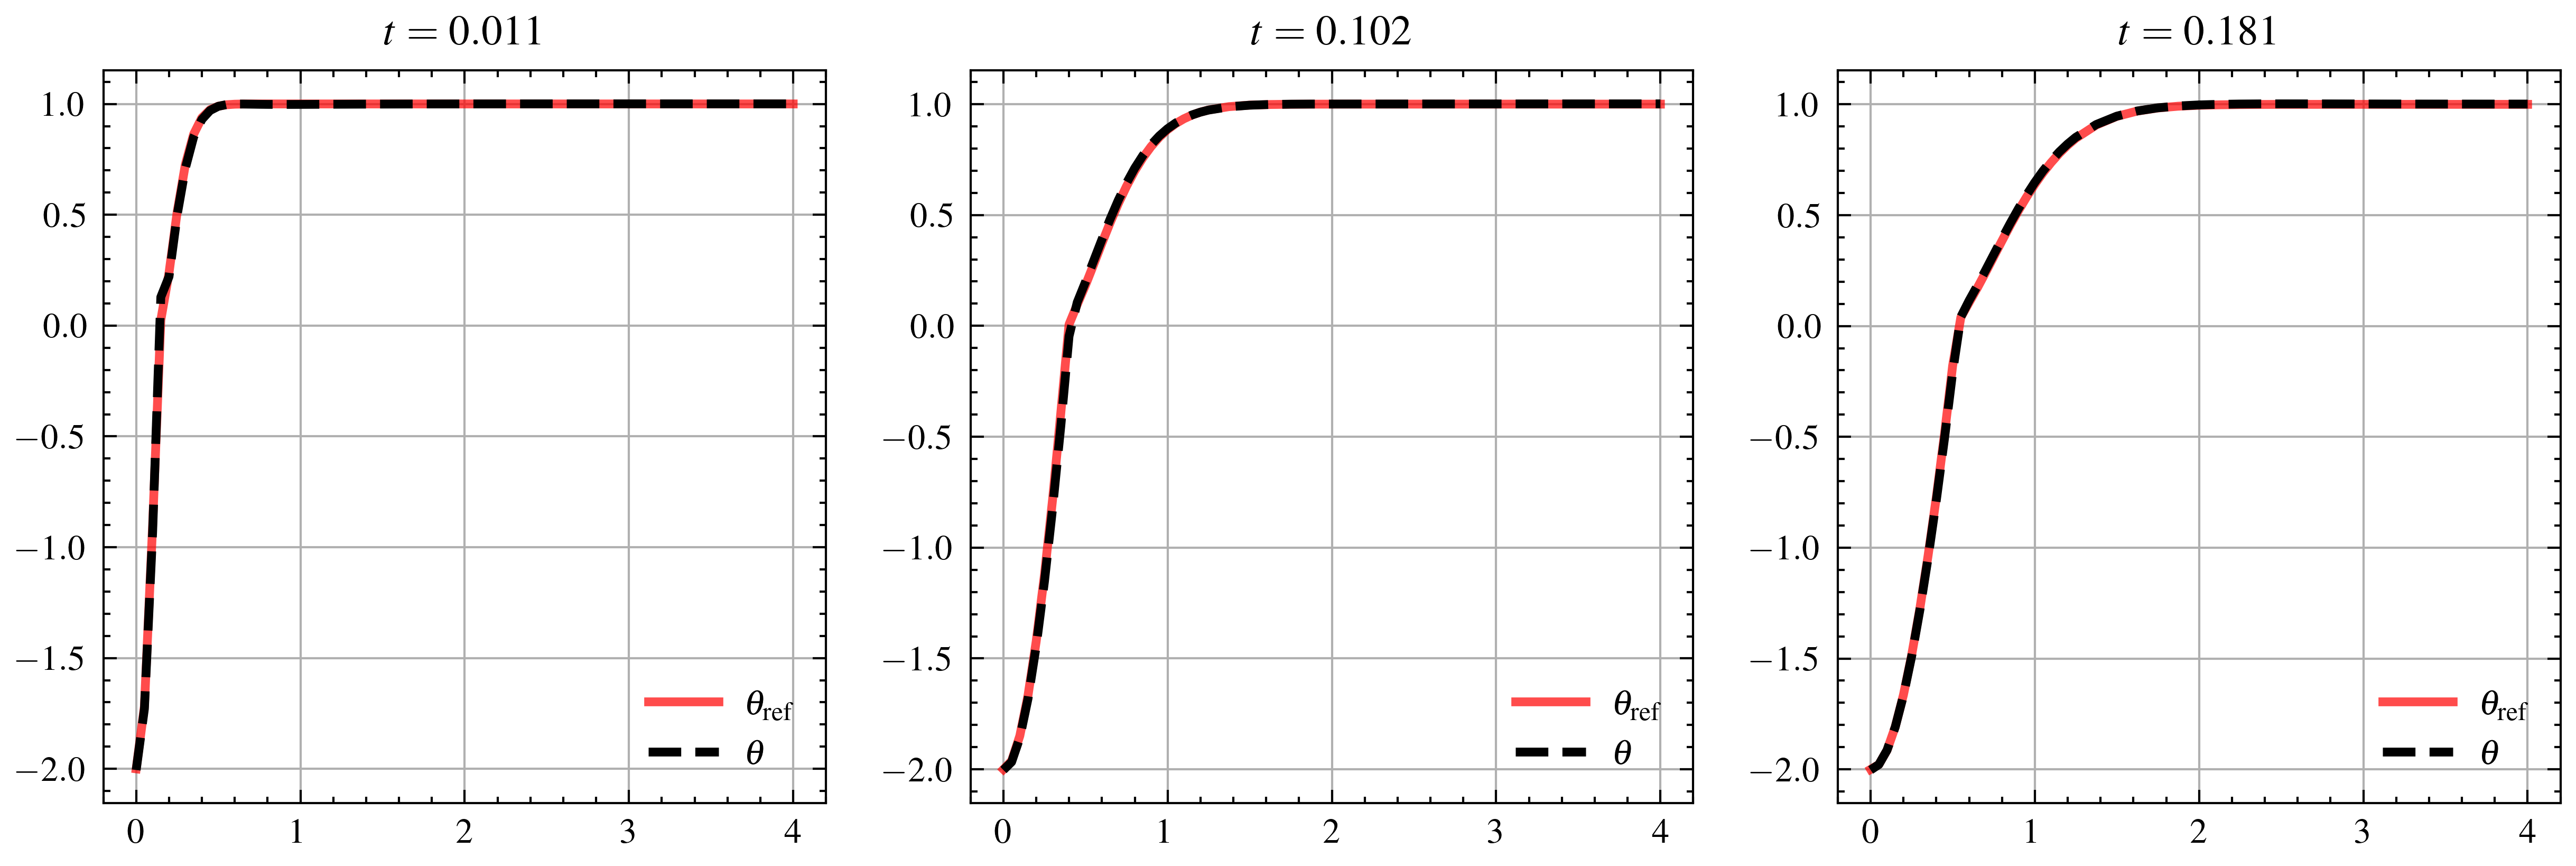

In [45]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

i = 0
j = 8
k = -1

vis_list = [i, j, k]

for a, b in enumerate(vis_list):
    axs[a].grid(True)
    axs[a].plot(x, np.diag(T_ref[b]), lw=2, c='red', alpha=.7, label=r'$\theta_\mathrm{ref}$')
    axs[a].plot(x, np.diag(T_pred[b]), '--k', lw=2, label=r'$\theta$')
    axs[a].set_title(r"$t = %.3f$"%(times[b]))
    axs[a].legend()

#axs[1].axvline(x=0.35, color='r', linestyle='-')


if True:
    plt.savefig(savefile+"2D_inst.pdf")
    plt.savefig(savefile+"2D_inst.png")
plt.show()

In [55]:
run1 = [
    1.545594132039695978e-04, 
    1.078269360732519999e-05, 
    6.892243865877389908e-03, 
    1.142662391066551208e-02,
    6*60 + 32
]

run2 = [
    4.773753462359309196e-04, 
    7.884907972766086459e-05, 
    4.107636585831642151e-02,
    1.995861716568470001e-02,
    9*60 + 12
]

run3 = [
    1.520838413853198290e-04, 
    1.048518242896534503e-05, 
    6.752860266715288162e-03, 
    1.256783679127693176e-02,
    6*60 + 36
]

In [56]:
print(np.mean([run1, run2, run3], axis=0))
print(np.std([run1, run2, run3], axis=0)* 100)

[2.61339534e-04 3.33723186e-05 1.82404900e-02 1.46510260e-02
 4.46666667e+02]
[1.52763731e-02 3.21571556e-03 1.61475029e+00 3.78184127e-01
 7.44998136e+03]


In [59]:
1.52763731e-02

0.0152763731